In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model

2026-02-26 16:09:49.097070: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 16:09:50.198798: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 16:09:53.723966: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
cifar10 = tf.keras.datasets.cifar10 
(x_train, y_train), (x_test, y_test) = cifar10.load_data() #carregamento base de dados

x_train, x_test = x_train / 255.0, x_test / 255.0 #normaliznado em 0 até 1
y_train, y_test = y_train.flatten(), y_test.flatten() #deixando em um vetor

print(x_train.shape,  y_train.shape) 

/home/Ront/banana/lib64/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3) (50000,)


In [3]:
K = len(set(y_train))
K

10

In [4]:
i = Input(shape=x_train[0].shape) # camada de entrada

x = Conv2D(32, (3, 3), strides=2, activation='relu', padding='same')(i) 
x = BatchNormalization()(x)

x = Conv2D(32, (3, 3), strides=2, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2,2)(x) # diminuir dimensão da imagem

x = Conv2D(64, (3, 3),  activation='relu', padding='same')(x) # segunda
x = BatchNormalization()(x) # normalizar os dados

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x) 
x = BatchNormalization()(x)#normalizar os dados
x = MaxPooling2D(2,2)(x)

x = Conv2D(128, (3, 3),  activation='relu', padding='same')(x) # terceira
x = BatchNormalization()(x) # normalizar os dados

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x) 
x = BatchNormalization()(x) # normalizar os dados
x = MaxPooling2D(2,2)(x) # diminuir dimensão da imagem

x = Flatten()(x) 
 
x = Dropout(0.2)(x) # dropout para evitar overffiting
x = Dense(1024, activation='relu')(x) # camadad densa
x = Dropout(0.2)(x) # denovo, evitando overfitting

x = Dense(K, activation='softmax')(x) # camada de saída

model = Model(i, x)

2026-02-26 16:10:18.158195: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
model.compile(optimizer = 'adam', 
              loss = 'sparse_categorical_crossentropy', 
              metrics=['accuracy'])
r = model.fit(x_train,y_train, validation_data=(x_test, y_test), epochs = 5)

2026-02-26 16:10:40.078147: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/5
  15/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.1461 - loss: 2.4791

2026-02-26 16:10:57.520218: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19537920 exceeds 10% of free system memory.
2026-02-26 16:10:57.520266: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19537920 exceeds 10% of free system memory.
2026-02-26 16:10:57.523643: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 13630464 exceeds 10% of free system memory.
2026-02-26 16:10:57.537916: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19537920 exceeds 10% of free system memory.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.4569 - loss: 1.5063 - val_accuracy: 0.5007 - val_loss: 1.4479
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5759 - loss: 1.1952 - val_accuracy: 0.5895 - val_loss: 1.1717
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6356 - loss: 1.0494 - val_accuracy: 0.6246 - val_loss: 1.0707
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6726 - loss: 0.9413 - val_accuracy: 0.6383 - val_loss: 1.0533
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6987 - loss: 0.8588 - val_accuracy: 0.6469 - val_loss: 1.0337


In [6]:
batch_size = 32
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1,
                                                           horizontal_flip=True)
train_generator = data_generator.flow(x_train, y_train, batch_size)
steps_per_epoch = x_train.shape[0] // batch_size
r = model.fit(train_generator, validation_data=(x_test, y_test), epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6505 - loss: 1.0124 - val_accuracy: 0.6615 - val_loss: 0.9869
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.6660 - loss: 0.9664 - val_accuracy: 0.6793 - val_loss: 0.9184
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6732 - loss: 0.9341 - val_accuracy: 0.6797 - val_loss: 0.9418
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6805 - loss: 0.9147 - val_accuracy: 0.6980 - val_loss: 0.8713
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.6926 - loss: 0.8816 - val_accuracy: 0.6783 - val_loss: 0.9469


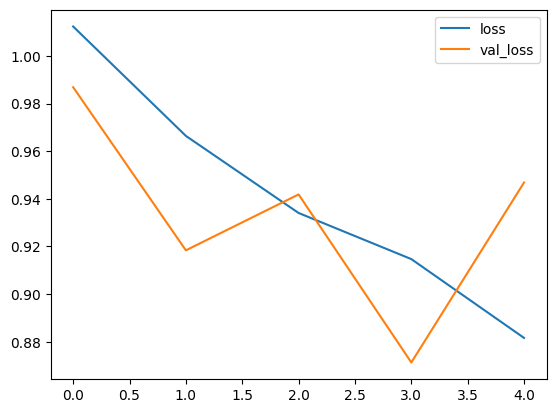

In [13]:
# taxas de erro por iteração
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

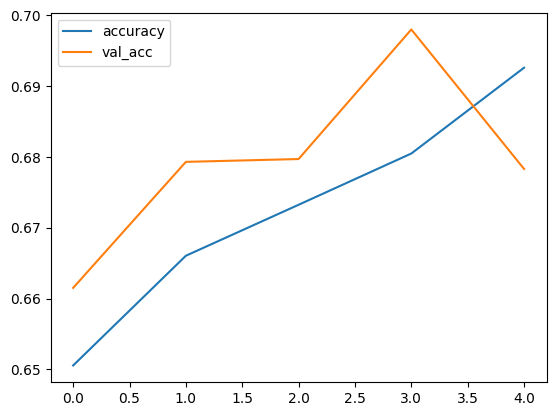

In [14]:
# taxas de erro e acurácia
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Confusion matrix, without normalization
[[683  33  44  21  21   3  19  21  99  56]
 [  8 816   2   4   1   3  19   2  28 117]
 [ 60  13 531  48  78  39 169  32  10  20]
 [ 12  17  48 429  49 143 218  36  14  34]
 [ 12   5  48  47 539  12 241  73  14   9]
 [  7   9  48 169  37 493 147  70   5  15]
 [  2   6  22  15   8  11 927   3   1   5]
 [  9   7  23  33  46  39  65 744   2  32]
 [ 48  43  13  14   5   0  16   5 828  28]
 [ 19 103   4  15   1   2  31   7  25 793]]


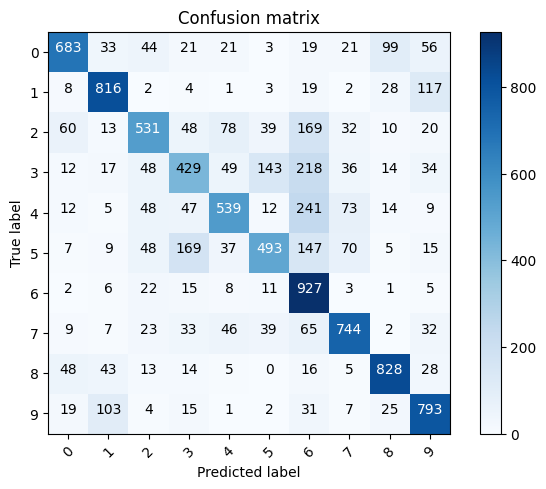

In [9]:
# Matriz de confusão
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm,
                          classes, # Classes
                          normalize=False, # Normalização
                          title='Confusion matrix', 
                          cmap=plt.cm.Blues # Cor
                          ):
    # normalização da matriz 
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)
    
    # plotagem da matriz 
    plt.imshow(cm, interpolation='nearest', cmap=cmap) # imagem da matriz 
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes)) # Marcas
    plt.xticks(tick_marks, classes, rotation=45) # rotulos do eixo x 
    plt.yticks(tick_marks, classes) # rotulos do eixo y
    
    # formatação dos números
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2. # limiar para a cor do texto
    # adicionando texto na matriz
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black')
    
    # adicionando rotulos
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# fazendo a predição
p_test = model.predict(x_test).argmax(axis=1)
# gerando a matriz de confusão
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [11]:
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       132,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291,648 (4.93 MB)

 Trainable params: 430,250 (1.64 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 860,502 (3.28 MB)